In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Basic Statistics ===')
df.describe()

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Basic Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# 0 values medically impossible hain in columns mein
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0 ko NaN se replace karo
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# NaN ko median se fill karo
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

print('Cleaning complete!')
print('\nMissing values after cleaning:')
print(df.isnull().sum())
df.head()

Cleaning complete!

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


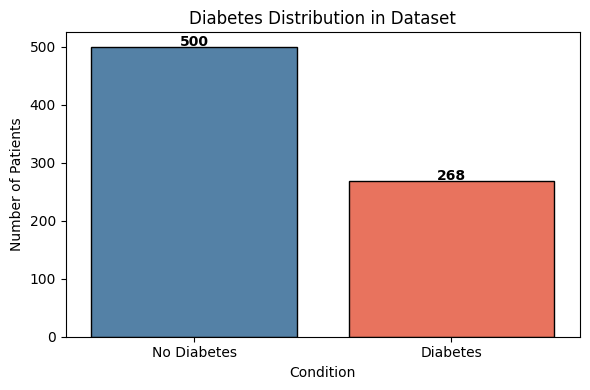

No Diabetes : 500
Diabetes    : 268


In [5]:
counts = df['Outcome'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values,
            palette=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.title('Diabetes Distribution in Dataset')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'No Diabetes : {counts[0]}')
print(f'Diabetes    : {counts[1]}')

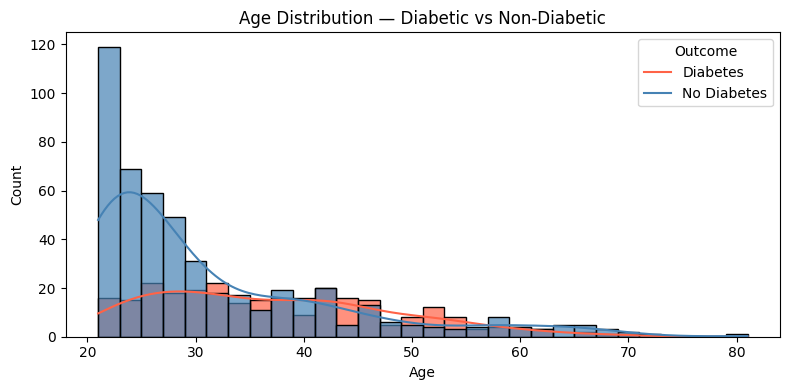

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Outcome', bins=30,
             kde=True, palette={0: 'steelblue', 1: 'tomato'}, alpha=0.7)
plt.title('Age Distribution — Diabetic vs Non-Diabetic')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Diabetes', 'No Diabetes'])
plt.tight_layout()
plt.show()

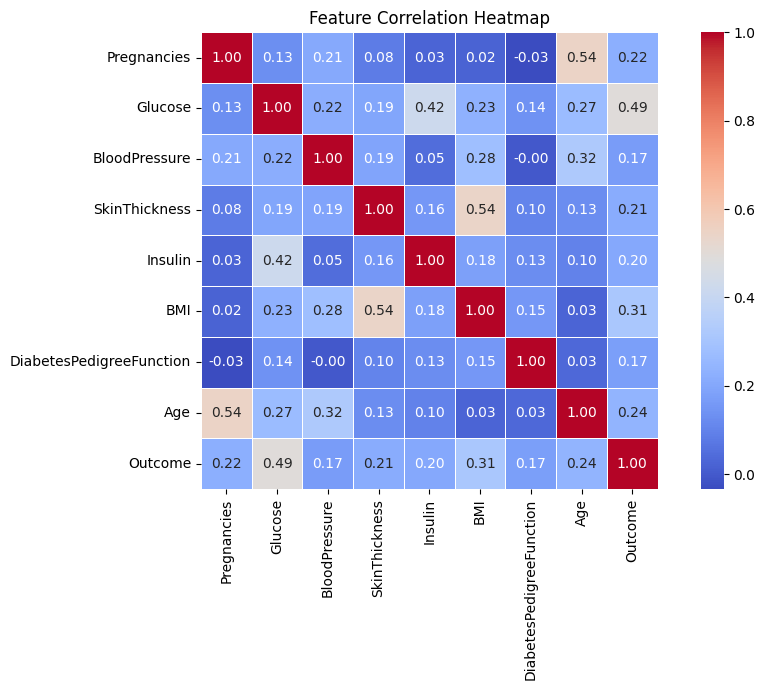

In [7]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print('Features (X) shape:', X.shape)
print('Target  (y) shape :', y.shape)
print('\nFeature columns:')
print(X.columns.tolist())

Features (X) shape: (768, 8)
Target  (y) shape : (768,)

Feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing  samples:', X_test.shape[0])

Training samples: 614
Testing  samples: 154


In [11]:
model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees banayega
    max_depth=5,           # har tree ki max depth
    min_samples_split=10,  # node split karne ke liye minimum samples
    min_samples_leaf=5,    # leaf node mein minimum samples
    random_state=42,
    n_jobs=-1              # saare CPU cores use karo — fast training
)

model.fit(X_train, y_train)
print('Random Forest trained successfully! ✅')
print(f'\nTotal Trees    : {model.n_estimators}')
print(f'Max Depth      : {model.max_depth}')
print(f'Total Features : {model.n_features_in_}')

Random Forest trained successfully! ✅

Total Trees    : 100
Max Depth      : 5
Total Features : 8


In [12]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')
print('=== Classification Report ===')
print(classification_report(y_test, y_pred,
                             target_names=['No Diabetes', 'Diabetes']))

Accuracy: 72.73%

=== Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.76      0.85      0.80       100
    Diabetes       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



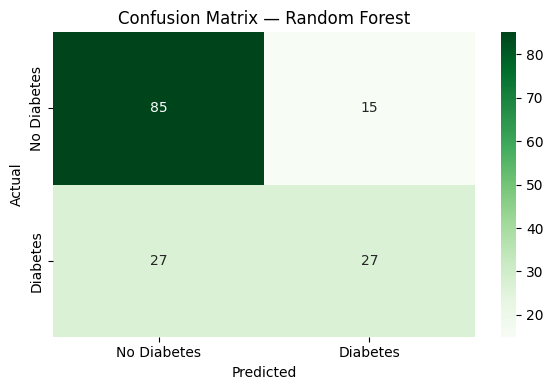


True  Negatives : 85  (Correctly predicted No Diabetes)
False Positives : 15  (No Diabetes predicted as Diabetes)
False Negatives : 27  (Diabetes missed by model) <- dangerous
True  Positives : 27  (Correctly predicted Diabetes)


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue  Negatives : {tn}  (Correctly predicted No Diabetes)')
print(f'False Positives : {fp}  (No Diabetes predicted as Diabetes)')
print(f'False Negatives : {fn}  (Diabetes missed by model) <- dangerous')
print(f'True  Positives : {tp}  (Correctly predicted Diabetes)')

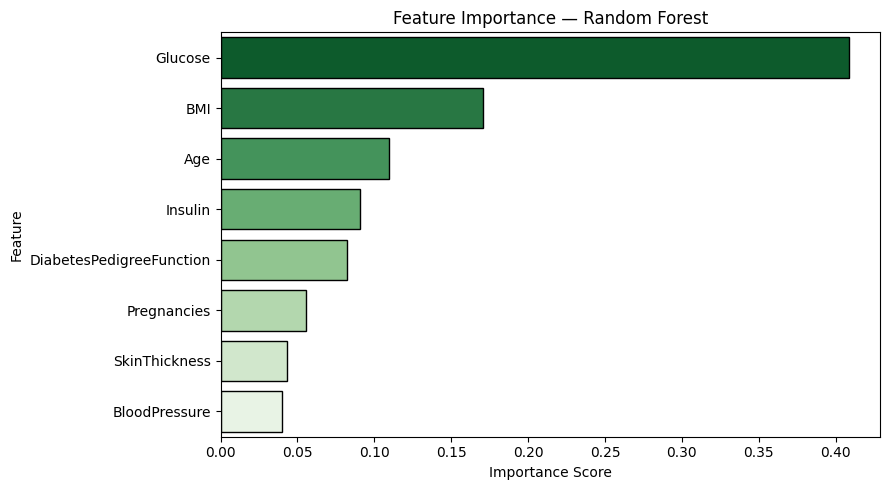


Feature Importance Scores:
Glucose                     0.408456
BMI                         0.170548
Age                         0.109362
Insulin                     0.090964
DiabetesPedigreeFunction    0.081992
Pregnancies                 0.055633
SkinThickness               0.042959
BloodPressure               0.040086
dtype: float64


In [14]:
feature_names  = df.drop(columns=['Outcome']).columns
importances    = pd.Series(model.feature_importances_, index=feature_names)
importances    = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index,
            palette='Greens_r', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nFeature Importance Scores:')
print(importances)

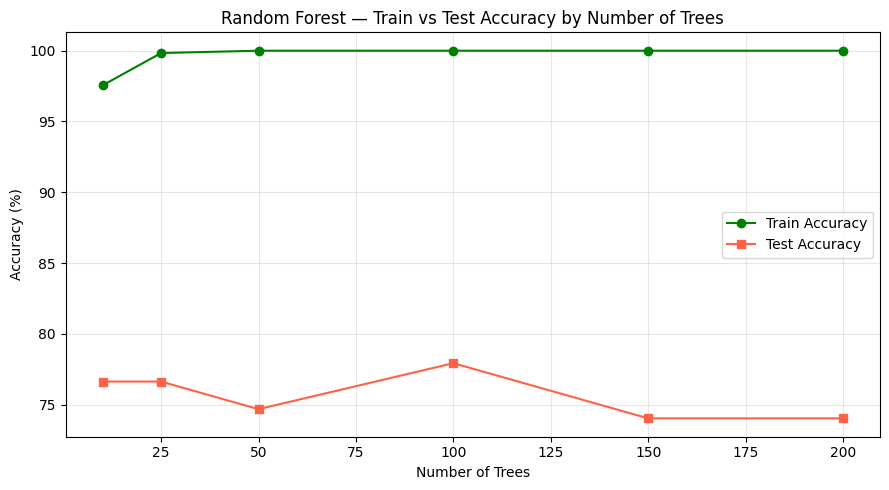

In [15]:
tree_range  = [10, 25, 50, 100, 150, 200]
train_accs  = []
test_accs   = []

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, rf.predict(X_train)) * 100)
    test_accs.append(accuracy_score(y_test,  rf.predict(X_test))  * 100)

plt.figure(figsize=(9, 5))
plt.plot(tree_range, train_accs, marker='o', label='Train Accuracy', color='green')
plt.plot(tree_range, test_accs,  marker='s', label='Test Accuracy',  color='tomato')
plt.title('Random Forest — Train vs Test Accuracy by Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('=' * 45)
print('         FINAL MODEL SUMMARY')
print('=' * 45)
print(f'  Algorithm       : Random Forest')
print(f'  Dataset         : Pima Indians Diabetes')
print(f'  Total Trees     : {model.n_estimators}')
print(f'  Total Samples   : {len(df)}')
print(f'  Training Size   : {X_train.shape[0]}')
print(f'  Testing Size    : {X_test.shape[0]}')
print(f'  Accuracy        : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  Diabetes Recall : {tp/(tp+fn)*100:.2f}%')
print(f'  Healthy Recall  : {tn/(tn+fp)*100:.2f}%')
print(f'  True Positives  : {tp}')
print(f'  True Negatives  : {tn}')
print(f'  False Positives : {fp}')
print(f'  False Negatives : {fn}')
print('=' * 45)


         FINAL MODEL SUMMARY
  Algorithm       : Random Forest
  Dataset         : Pima Indians Diabetes
  Total Trees     : 100
  Total Samples   : 768
  Training Size   : 614
  Testing Size    : 154
  Accuracy        : 72.73%
  Diabetes Recall : 50.00%
  Healthy Recall  : 85.00%
  True Positives  : 27
  True Negatives  : 85
  False Positives : 15
  False Negatives : 27
